# Project 4 --- K-Means Manual Implementation

- Pedro Mauri Mtz - A01029143

Se implementó el algoritmo K-means desde cero con NumPy para comprimir una imagen mediante cuantización de color. Cada píxel se trata como un punto de 3 dimensiones (R, G, B) normalizado entre 0 y 1, y K-means los agrupa en K = 16 clusters, de modo que cada centroide representa un color de una paleta de 16.

El algoritmo alterna dos pasos: asignar cada píxel al centroide más cercano (distancia euclidiana) y recalcular cada centroide como el promedio de los píxeles asignados, hasta converger o llegar al máximo de iteraciones.

Finalmente, la imagen se reconstruye reemplazando cada píxel por el color de su centroide. Así se pasa de 24 bits por píxel a 4 bits (un índice de la paleta), una reducción de aproximadamente 6 veces en tamaño, a cambio de una pérdida visual moderada de detalle y colores.

## Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os

ROOT = os.path.abspath(os.path.join(os.getcwd(), "../"))

## Load Data

In [3]:
"""
Leer archivo de datos de imagen
"""
def load_image_data():
    with open(os.path.join(ROOT, "Datasets/bird_small.txt")  , "r") as file:
        # Para encabezado:
        dims = list(map(int, file.readline().strip().split()))

        # Vector con todos los valores de los pixeles
        pixel_values = [int(line.strip()) for line in file if line.strip()]

    data = np.array(pixel_values, dtype=np.uint8)

    # Remodelar los datos a la forma original de la imagen
    image_reshaped = data.reshape(dims[2], dims[0], dims[1]).transpose(1, 2, 0)
    
    # Normalizar los datos a un rango de 0 a 1 para el procesamiento
    image_normalized = image_reshaped / 255.0

    X = image_normalized.reshape(-1, 3) # Cada fila es un píxel (R, G, B)
    
    return X, image_normalized

## K-Means Implementation

In [4]:
"""
Inicializa K centroides seleccionando K puntos aleatorios de X.
"""
def kMeansInitCentroids(X, K):
    m, n = X.shape
    # Genera K índices aleatorios sin repetición del rango de filas de X
    random_indices = np.random.permutation(m)
    # Selecciona los primeros K puntos como centroides
    centroids = X[random_indices[:K]]

    return centroids

In [5]:
"""
Asigna cada dato a su centroide más cercano.
"""
def findClosestCentroids(X, centroids):
    # Distancia de cada píxel a cada centroide: matriz de forma (m, K)
    distances = np.linalg.norm(X[:, np.newaxis, :] - centroids[np.newaxis, :, :], axis = 2)

    return np.argmin(distances, axis = 1)

In [6]:
"""
Recalcula los centroides como la media de los puntos asignados a cada cluster.
"""
def computeCentroids(X, idx, K, previous_centroids):

    m, n = X.shape
    centroids = np.zeros((K, n))
    
    for k in range(K):
        points_in_cluster = X[idx == k]

        if len(points_in_cluster) > 0:
            centroids[k] = np.mean(points_in_cluster, axis = 0)
        else:
            # Cluster vacío: conserva el centroide anterior en vez de quedar en negro (0, 0, 0)
            centroids[k] = previous_centroids[k]
            
    return centroids

In [7]:
"""
Ejecuta el algoritmo K-means completo.
"""
def runkMeans(X, initial_centroids, max_iters):
    K = initial_centroids.shape[0]
    centroids = initial_centroids
    
    for i in range(max_iters):
        print(f"Iteración de K-means {i + 1}/{max_iters}...")
        
        # Asignar cada punto a su centroide más cercano
        idx = findClosestCentroids(X, centroids)
        
        # Recalcular los centroides (conserva el anterior si un cluster queda vacío)
        new_centroids = computeCentroids(X, idx, K, centroids)
        
        # Si los centroides ya no cambian, el algoritmo convergió
        if np.allclose(new_centroids, centroids):
            centroids = new_centroids
            print("K-means convergió.")
            break
        
        centroids = new_centroids
        
    return centroids, idx

## Main Section of the Code

In [8]:
K = 16
max_iters = 10

# Cargar los datos del archivo de texto
X, original_image = load_image_data()

# Inicializar los centroides (los 16 colores iniciales)
initial_centroids = kMeansInitCentroids(X, K)

# Correr K-means para encontrar los 16 colores óptimos
final_centroids, idx = runkMeans(X, initial_centroids, max_iters)

# Reconstruir la imagen comprimida tomando los centroides finales
# y asignado a cada píxel el color del centroide que le fue asignado
X_recovered = final_centroids[idx, :]

# Remodelar el vector de píxeles a las dimensiones de la imagen original
img_compressed = X_recovered.reshape(original_image.shape)

Iteración de K-means 1/10...
Iteración de K-means 2/10...
Iteración de K-means 3/10...
Iteración de K-means 4/10...
Iteración de K-means 5/10...
Iteración de K-means 6/10...
Iteración de K-means 7/10...
Iteración de K-means 8/10...
Iteración de K-means 9/10...
Iteración de K-means 10/10...


## Results

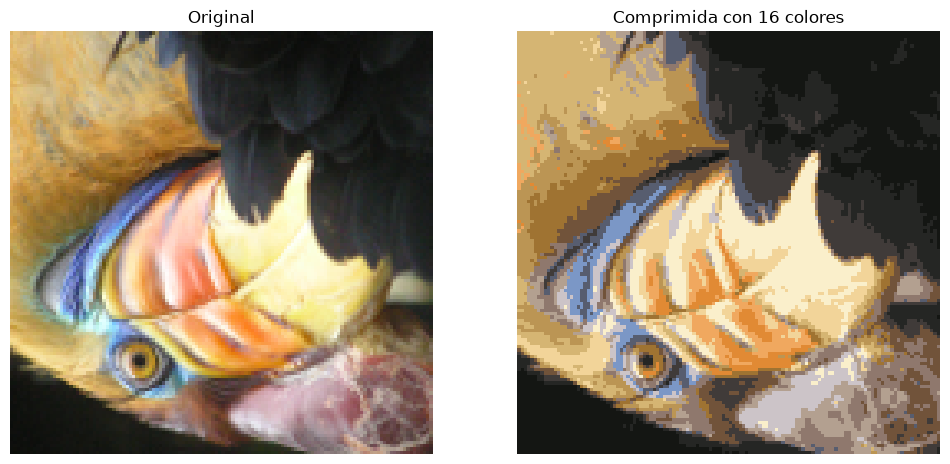

In [9]:
# Mostrar las imágenes para comparar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (12, 6))
# Visualizar la imagen original
ax1.imshow(original_image)
ax1.set_title('Original')
ax1.axis('off')
# Visualizar la imagen comprimida
ax2.imshow(img_compressed)
ax2.set_title(f'Comprimida con {K} colores')
ax2.axis('off')
plt.show()